# 01 - Dataset Inventory and Leakage Audit

Builds a sample-level manifest for each dataset and **quantifies the leakage present
in the published protocols**. This notebook produces the evidence for the
"Dataset and Experimental Protocol" section of the revised paper.

Nothing here reads bulk signal data: Tomasov manifests come from the small boolean
annotation masks (`.npy`) and Cao manifests from filenames, so the whole notebook
runs in seconds.

## The two datasets

| | Cao et al. 2023 | Tomasov et al. 2025 |
|---|---|---|
| Sensing principle | intensity-based Phi-OTDR | phase-sensitive OTDR (OptaSense ODH-F) |
| Classes | 6 | 9 |
| Spatial channels | 12 (10 m spacing) | 1,700 (1.02 m spacing) |
| Sample unit | pre-segmented 10000 x 12 `.mat` | continuous HDF5 + polygon annotations |
| Released split | fixed 8:2 folders | none (users split it themselves) |

They share no event taxonomy and no hardware. That is the point: if the same feature
pipeline ranks the same way on both, the finding is about the *method*, not about one
campus fibre.

In [1]:
import sys
from pathlib import Path
EXPERIMENT_DIR = Path(r"/mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Experiment")
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dasfe import config as C, manifests as M

pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

## 1. Cao 2023 - manifest

Filenames encode `<date>_<operator>_<event>_<session>_data_<n>.mat`. The **session** is
the unit of statistical independence: all samples carved out of one continuous
recording share the same fibre state, the same operator, the same soil conditions and
the same background noise realisation.

In [2]:
cao = M.build_cao_manifest()
print(f"{len(cao):,} .mat records")
print(f"  dates     : {cao.date.nunique()}")
print(f"  operators : {cao.operator.nunique()}")
print(f"  sessions  : {cao.session_id.nunique()}")
print(f"  classes   : {cao.label.nunique()}")

zero = cao[cao.n_bytes == 0]
if len(zero):
    print(f"\n{len(zero)} zero-byte (corrupt) record(s) - excluded downstream:")
    display(zero[["label", "official_split", "filename"]])

display(M.summarise(cao, "session_id"))

15,419 .mat records
  dates     : 21
  operators : 16
  sessions  : 441
  classes   : 6

1 zero-byte (corrupt) record(s) - excluded downstream:


,label,official_split,filename
12335,background,test,220112_cxm_background_01_single_data_2.mat


,label,n_windows,n_groups,pct
0,background,2946,63,19.106297
1,shake,2728,63,17.692457
2,knock,2530,60,16.408327
3,dig,2512,75,16.291588
4,walk,2450,58,15.889487
5,water,2253,122,14.611843


### 1.1 Leakage in the published 8:2 split

Cao et al. released fixed `Training/` and `Test/` folders. The audit below checks
whether a recording session ever contributes samples to both.

In [3]:
audit = M.audit_cao_official_split(cao)
n_both = int(audit.in_both.sum())
pct = 100 * n_both / len(audit)

print(f"recording sessions            : {len(audit)}")
print(f"sessions in BOTH train & test : {n_both}  ({pct:.1f}%)")
print(f"sessions in train only        : {int(((audit.n_train>0)&(audit.n_test==0)).sum())}")
print(f"sessions in test only         : {int(((audit.n_train==0)&(audit.n_test>0)).sum())}")

leaked = cao.merge(audit[["session_id", "in_both"]], on="session_id")
leaked_test = leaked[(leaked.official_split == "test") & (leaked.in_both)]
print(f"\ntest samples whose session also appears in train: "
      f"{len(leaked_test):,} / {int((cao.official_split=='test').sum()):,} "
      f"({100*len(leaked_test)/max((cao.official_split=='test').sum(),1):.1f}%)")

display(audit.sort_values("n_test", ascending=False).head(10))

recording sessions            : 441
sessions in BOTH train & test : 423  (95.9%)
sessions in train only        : 17
sessions in test only         : 1

test samples whose session also appears in train: 3,083 / 3,084 (100.0%)


,session_id,n_train,n_test,in_both
239,220121|cxm|background|background_02_single,71,26,True
258,220122|cxm|knock|knock_08_single,87,25,True
238,220121|cxm|background|background_01_single,87,25,True
256,220122|cxm|knock|knock_06_single,76,23,True
255,220122|cxm|knock|knock_05_single,78,23,True
316,220428|dig|dig|07_single,83,23,True
240,220121|cxm|background|background_03_single,89,23,True
242,220121|cxm|background|background_05_single,89,22,True
254,220122|cxm|knock|knock_04_single,74,22,True
350,220517|bkg|background|evening_22_single,77,22,True


> **Finding.** Almost every session straddles the released split, so nearly the whole
> official test set is drawn from recordings the model has already seen. Accuracies
> reported on this split - including the SVM and CNN baselines shipped with the
> dataset - measure within-recording memorisation as much as event recognition.
>
> The revised protocol replaces it with a session-grouped split (notebook 02).

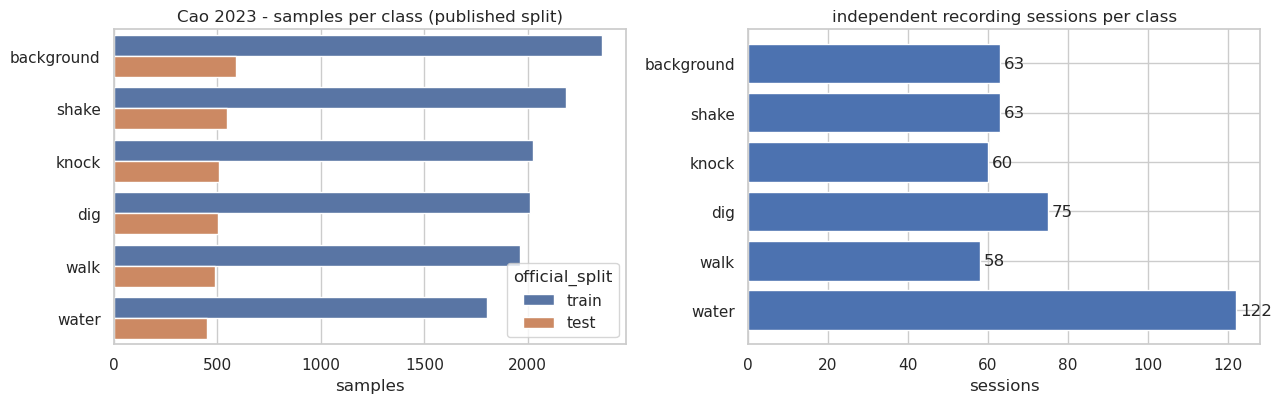

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

order = cao.label.value_counts().index
sns.countplot(data=cao, y="label", order=order, hue="official_split", ax=axes[0])
axes[0].set_title("Cao 2023 - samples per class (published split)")
axes[0].set_xlabel("samples"); axes[0].set_ylabel("")

sess = cao.groupby("label").session_id.nunique().reindex(order)
axes[1].barh(sess.index, sess.values, color="#4C72B0")
axes[1].invert_yaxis()
axes[1].set_title("independent recording sessions per class")
axes[1].set_xlabel("sessions")
for i, v in enumerate(sess.values):
    axes[1].text(v + 1, i, str(v), va="center")

plt.tight_layout()
plt.savefig(C.results_dir("cao", "00_inventory") / "class_and_session_counts.png", dpi=200)
plt.show()

### 1.2 Acquisition-campaign structure

Cao et al. used two fibre spans (5.1 km and 10.1 km) at different times, giving two
different sampling rates (0.8 s vs 1.25 s for the same 10,000 points). The release
carries no per-file marker, but the recording dates cluster into two campaigns, which
is why `date` is used as the grouping variable for the stricter leave-one-date-out
robustness split in notebook 08.

In [5]:
by_date = (cao.groupby("date")
             .agg(n=("filename", "size"), classes=("label", "nunique"),
                  sessions=("session_id", "nunique"))
             .sort_index())
by_date["campaign"] = np.where(by_date.index.str[:4] <= "2203", "Jan-Feb 2022", "Apr-May 2022")
display(by_date)

print("\nnominal fs used:", C.CAO.fs, "Hz")
print("sensitivity alternatives:", C.CAO.fs_alternatives, "Hz  (checked in notebook 08)")

,n,classes,sessions,campaign
date,,,,
220104,108,1,5,Jan-Feb 2022
220110,236,1,12,Jan-Feb 2022
220111,410,1,11,Jan-Feb 2022
220112,832,2,24,Jan-Feb 2022
220113,626,2,20,Jan-Feb 2022
220115,538,1,27,Jan-Feb 2022
220116,2130,3,56,Jan-Feb 2022
220117,1690,5,52,Jan-Feb 2022
220118,1061,1,31,Jan-Feb 2022



nominal fs used: 10000.0 Hz
sensitivity alternatives: (8000.0, 12500.0) Hz  (checked in notebook 08)


## 2. Tomasov 2025 - manifest

Each recording is a continuous HDF5 stream (`Acquisition/Raw[0]/RawData`, shape
`n_time x 1700`) plus a hand-drawn annotation rasterised to a boolean mask of shape
`(n_blocks, n_loci)`, where one block is `WIN_HOP = 2048` raw samples.

A manifest row is one annotated `(time-block, locus)` cell, i.e. one analysis window.
The `t0`/`t1` columns record exactly which raw samples that window reads - the guard
band in notebook 02 depends on them.

In [6]:
tom = M.build_tomasov_manifest()
print(f"{len(tom):,} annotated windows")
print(f"  recordings : {tom.recording_id.nunique()}")
print(f"  zones      : {tom.zone_id.nunique()}  (zone = {C.ZONE_BLOCKS} blocks "
      f"~ {C.ZONE_BLOCKS*C.WIN_HOP/C.TOMASOV.fs:.2f} s)")
print(f"  classes    : {tom.label.nunique()}")

display(M.summarise(tom, "zone_id"))

439,754 annotated windows
  recordings : 16
  zones      : 339  (zone = 21 blocks ~ 2.15 s)
  classes    : 9


,label,n_windows,n_groups,pct
0,regular,210023,37,47.759202
1,car,58017,59,13.193058
2,construction,54832,24,12.468789
3,fence,43981,36,10.001273
4,walk,19155,73,4.355844
5,manipulation,17710,32,4.027252
6,longboard,15367,38,3.494454
7,running,13877,25,3.155628
8,openclose,6792,15,1.544500


In [7]:
rec = (tom.groupby(["label", "recording_id"])
         .agg(windows=("block", "size"),
              blocks=("block", "nunique"),
              loci=("locus", "nunique"),
              zones=("zone_id", "nunique"))
         .reset_index())
print(f"{len(rec)} recordings; duration of each ~"
      f"{tom.n_blocks.iloc[0]*C.WIN_HOP/C.TOMASOV.fs:.1f} s")
display(rec)

single = rec.groupby("label").recording_id.nunique()
print("\nclasses represented by a SINGLE recording:",
      sorted(single[single == 1].index.tolist()))

16 recordings; duration of each ~22.6 s


,label,recording_id,windows,blocks,loci,zones
0,car,auto2_2023-04-17T124510+0100,2775,117,163,7
1,car,auto4_2023-06-06T144655+0100,7764,106,262,6
2,car,auto4_2023-06-06T145055+0100,37727,508,646,25
3,car,auto_2023-04-17T124152+0100,9751,363,162,21
4,construction,reconstruction1_2023-06-06T150714+0100,54832,494,184,24
5,fence,fence_2023-04-17T123117+0100,1091,57,58,9
6,fence,kopani_plot_2023-11-07T150207Z,26654,222,133,12
7,fence,plot_2023-11-07T150119Z,16236,292,66,15
8,longboard,longboard_2023-04-17T123543+0100,9801,361,197,18
9,longboard,longboardroad_2023-04-17T123638+0100,5566,321,99,20



classes represented by a SINGLE recording: ['construction', 'manipulation', 'openclose', 'regular', 'running']


> **Finding.** Five of the nine classes come from exactly one recording. A pure
> recording-level (leave-one-file-out) split is therefore impossible for the full
> 9-class problem - there would be no training data for those classes.
>
> The revised protocol splits on **contiguous spatio-temporal zones within each
> recording, with guard bands**, which removes the window-overlap leak completely
> while keeping every class present in every split. Classes with >= 2 recordings are
> *additionally* evaluated leave-one-recording-out in notebook 08, so the harder
> cross-recording question is answered where the data allows it.

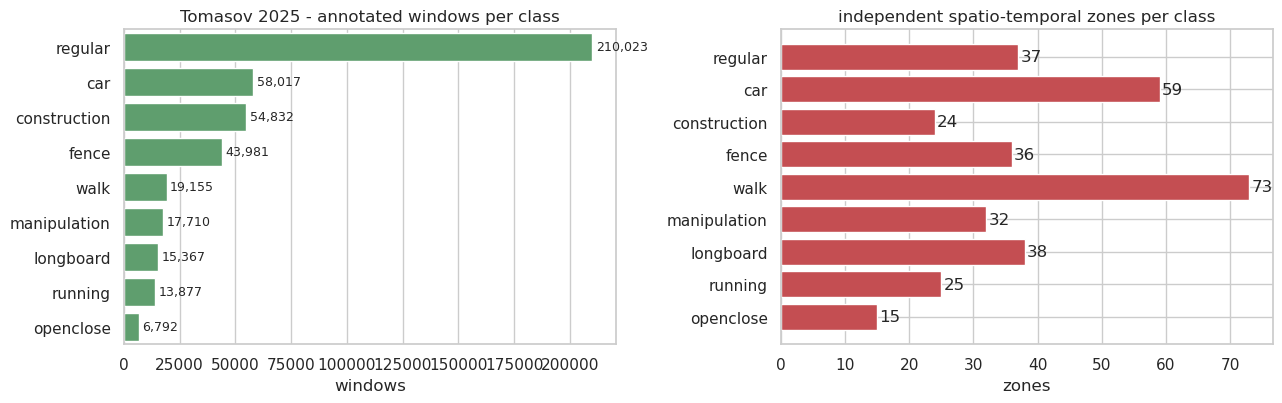

class imbalance ratio (max/min): 30.9x


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

order = tom.label.value_counts().index
sns.countplot(data=tom, y="label", order=order, color="#55A868", ax=axes[0])
axes[0].set_title("Tomasov 2025 - annotated windows per class")
axes[0].set_xlabel("windows"); axes[0].set_ylabel("")
for i, lbl in enumerate(order):
    axes[0].text(tom.label.value_counts()[lbl] + 1500, i,
                 f"{tom.label.value_counts()[lbl]:,}", va="center", fontsize=9)

z = tom.groupby("label").zone_id.nunique().reindex(order)
axes[1].barh(z.index, z.values, color="#C44E52")
axes[1].invert_yaxis()
axes[1].set_title("independent spatio-temporal zones per class")
axes[1].set_xlabel("zones")
for i, v in enumerate(z.values):
    axes[1].text(v + 0.3, i, str(v), va="center")

plt.tight_layout()
plt.savefig(C.results_dir("tomasov", "00_inventory") / "class_and_zone_counts.png", dpi=200)
plt.show()

print(f"class imbalance ratio (max/min): {tom.label.value_counts().max() / tom.label.value_counts().min():.1f}x")

### 2.1 Acquisition metadata read from the files

The paper stated `fs = 20 kHz`; here it is read from the HDF5 attributes rather than
assumed, and verified to be identical across recordings.

In [9]:
meta = []
for stem, sub in tom.groupby("recording_id"):
    a = M.read_tomasov_acquisition(sub.h5_path.iloc[0])
    meta.append({
        "recording": stem, "label": sub.label.iloc[0],
        "PulseRate_Hz": a["PulseRate"], "NumberOfLoci": a["NumberOfLoci"],
        "SpatialSampling_m": round(float(a["SpatialSamplingInterval"]), 4),
        "PulseWidth_ns": a["PulseWidth"], "Vendor": str(a["VendorCode"])[:28],
    })
meta = pd.DataFrame(meta)
display(meta)

assert meta.PulseRate_Hz.nunique() == 1, "recordings disagree on pulse rate"
assert float(meta.PulseRate_Hz.iloc[0]) == C.TOMASOV.fs, "config fs does not match the files"
print(f"\nOK - all {len(meta)} recordings share fs = {C.TOMASOV.fs:.0f} Hz, "
      f"{int(meta.NumberOfLoci.iloc[0])} loci")

,recording,label,PulseRate_Hz,NumberOfLoci,SpatialSampling_m,PulseWidth_ns,Vendor
0,auto2_2023-04-17T124510+0100,car,20000.0,1700,1.021,20.0,OptaSense IU Setup 1.8.6 c9c
1,auto4_2023-06-06T144655+0100,car,20000.0,1663,1.021,20.0,OptaSense IU Setup 1.8.6 c9c
2,auto4_2023-06-06T145055+0100,car,20000.0,1663,1.021,20.0,OptaSense IU Setup 1.8.6 c9c
3,auto_2023-04-17T124152+0100,car,20000.0,1700,1.021,20.0,OptaSense IU Setup 1.8.6 c9c
4,fence_2023-04-17T123117+0100,fence,20000.0,1700,1.021,20.0,OptaSense IU Setup 1.8.6 c9c
5,kopani_plot_2023-11-07T150207Z,fence,20000.0,1700,1.021,20.0,OptaSense IU Setup 1.8.6 c9c
6,longboard_2023-04-17T123543+0100,longboard,20000.0,1700,1.021,20.0,OptaSense IU Setup 1.8.6 c9c
7,longboardroad_2023-04-17T123638+0100,longboard,20000.0,1700,1.021,20.0,OptaSense IU Setup 1.8.6 c9c
8,manipulation_2023-04-17T122847+0100,manipulation,20000.0,1700,1.021,20.0,OptaSense IU Setup 1.8.6 c9c
9,openingclosing_2023-04-17T122658+0100,openclose,20000.0,1700,1.021,20.0,OptaSense IU Setup 1.8.6 c9c



OK - all 16 recordings share fs = 20000 Hz, 1700 loci


### 2.2 Why a random split leaks here

A window starting at block *b* reads blocks `b .. b+3`. Two windows one hop apart
share 6,144 of their 8,192 samples. The plot below shows the overlap structure that a
random split would scatter across train/val/test.

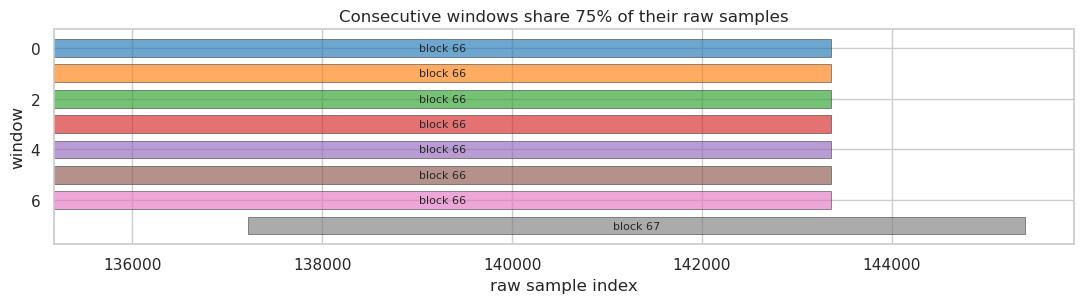

window = 8192 samples spanning 4 blocks; hop = 2048 samples
adjacent windows share 6,144 samples


In [10]:
bpw = C.WIN_LEN // C.WIN_HOP
demo = tom[tom.recording_id == tom.recording_id.iloc[0]].head(8).sort_values("block")

fig, ax = plt.subplots(figsize=(11, 3.2))
for i, (_, r) in enumerate(demo.iterrows()):
    ax.barh(i, C.WIN_LEN, left=r.t0, height=0.7,
            color=plt.cm.tab10(i % 10), alpha=0.65, edgecolor="k", linewidth=0.5)
    ax.text(r.t0 + C.WIN_LEN / 2, i, f"block {r.block}", ha="center", va="center", fontsize=8)
ax.set_xlabel("raw sample index"); ax.set_ylabel("window")
ax.set_title(f"Consecutive windows share {100*(1-C.WIN_HOP/C.WIN_LEN):.0f}% of their raw samples")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(C.results_dir("tomasov", "00_inventory") / "window_overlap.png", dpi=200)
plt.show()

print(f"window = {C.WIN_LEN} samples spanning {bpw} blocks; hop = {C.WIN_HOP} samples")
print(f"adjacent windows share {C.WIN_LEN - C.WIN_HOP:,} samples")

## 3. Persist the manifests

In [11]:
cao_out = C.results_dir("cao", "00_inventory")
tom_out = C.results_dir("tomasov", "00_inventory")

cao.to_parquet(cao_out / "manifest.parquet", index=False)
audit.to_csv(cao_out / "official_split_leakage_audit.csv", index=False)
M.summarise(cao, "session_id").to_csv(cao_out / "class_summary.csv", index=False)

tom.to_parquet(tom_out / "manifest.parquet", index=False)
rec.to_csv(tom_out / "recording_summary.csv", index=False)
meta.to_csv(tom_out / "acquisition_metadata.csv", index=False)
M.summarise(tom, "zone_id").to_csv(tom_out / "class_summary.csv", index=False)

print("cao     ->", cao_out)
print("tomasov ->", tom_out)

cao     -> /mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Results/cao/00_inventory
tomasov -> /mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Results/tomasov/00_inventory


### Table for the paper: dataset comparison

In [12]:
comparison = pd.DataFrame([
    {"property": "Sensing principle", "Cao 2023": "Intensity-based Phi-OTDR",
     "Tomasov 2025": "Phase-sensitive OTDR (OptaSense ODH-F)"},
    {"property": "Event classes", "Cao 2023": cao.label.nunique(),
     "Tomasov 2025": tom.label.nunique()},
    {"property": "Analysis windows", "Cao 2023": f"{len(cao):,}",
     "Tomasov 2025": f"{len(tom):,}"},
    {"property": "Spatial channels", "Cao 2023": C.CAO.n_channels,
     "Tomasov 2025": C.TOMASOV.n_channels},
    {"property": "Channel spacing", "Cao 2023": "10 m", "Tomasov 2025": "1.02 m"},
    {"property": "Sampling rate", "Cao 2023": "8-12.5 kHz (campaign dependent)",
     "Tomasov 2025": f"{C.TOMASOV.fs:.0f} Hz"},
    {"property": "Independent split groups",
     "Cao 2023": f"{cao.session_id.nunique()} sessions",
     "Tomasov 2025": f"{tom.zone_id.nunique()} zones / {tom.recording_id.nunique()} recordings"},
    {"property": "Imbalance ratio (max:min)",
     "Cao 2023": f"{cao.label.value_counts().max()/cao.label.value_counts().min():.1f}:1",
     "Tomasov 2025": f"{tom.label.value_counts().max()/tom.label.value_counts().min():.1f}:1"},
    {"property": "Published-split leakage",
     "Cao 2023": f"{n_both}/{len(audit)} sessions ({pct:.1f}%) span train and test",
     "Tomasov 2025": "no split published; 75% window overlap makes random splits invalid"},
])
display(comparison)
comparison.to_csv(C.results_dir("shared", "tables") / "dataset_comparison.csv", index=False)

,property,Cao 2023,Tomasov 2025
0,Sensing principle,Intensity-based Phi-OTDR,Phase-sensitive OTDR (OptaSense ODH-F)
1,Event classes,6,9
2,Analysis windows,"15,419","439,754"
3,Spatial channels,12,1700
4,Channel spacing,10 m,1.02 m
5,Sampling rate,8-12.5 kHz (campaign dependent),20000 Hz
6,Independent split groups,441 sessions,339 zones / 16 recordings
7,Imbalance ratio (max:min),1.3:1,30.9:1
8,Published-split leakage,423/441 sessions (95.9%) span train and test,no split published; 75% window overlap makes r...


---
**Next:** `02_leakage_safe_splits.ipynb` - build grouped splits with guard bands and
*prove* with executable audits that no raw sample is shared between splits.